In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("Multiple.csv")

In [3]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [5]:
## We don't need column Unnamed: 0,year,month so we can delete it
df.drop(columns=["year","Unnamed: 0","month"],axis=1,inplace=True)

In [6]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [7]:
## Check the missing value
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

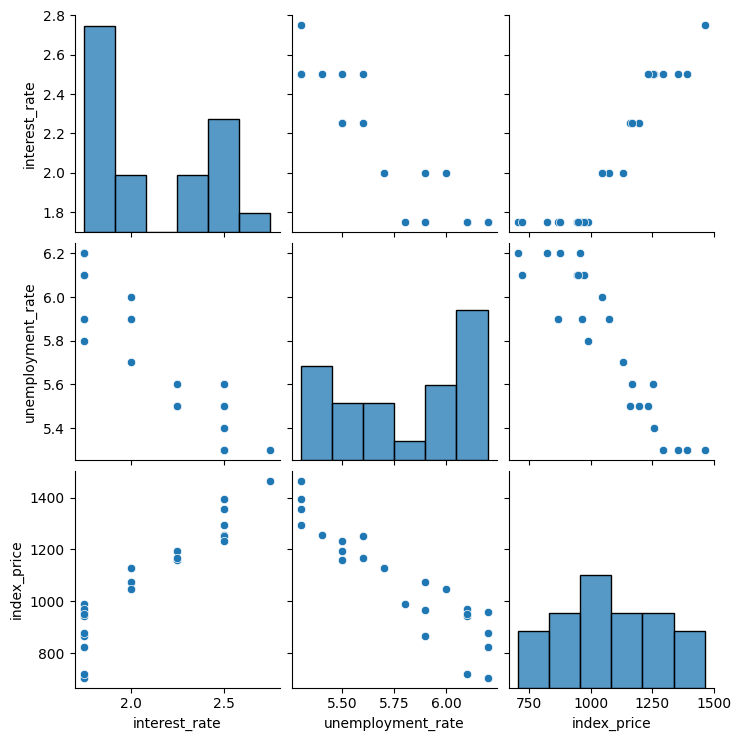

In [9]:
sns.pairplot(df)
## Conclusion As interest rate increases index price increase
## As unployement rate increases index price decreases

In [10]:
## check the correclation
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.924326,0.928948
unemployment_rate,-0.924326,1.000000,-0.921060
index_price,0.928948,-0.921060,1.000000


In [13]:
## Seprate the input and optput parameter
## Here interest rate and unemployement_rate is out input parameter
X=df.iloc[:,:-1]
y=df.iloc[:,-1]
y

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     988
15     943
16     958
17     971
18     949
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [14]:
## Now seprate the train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

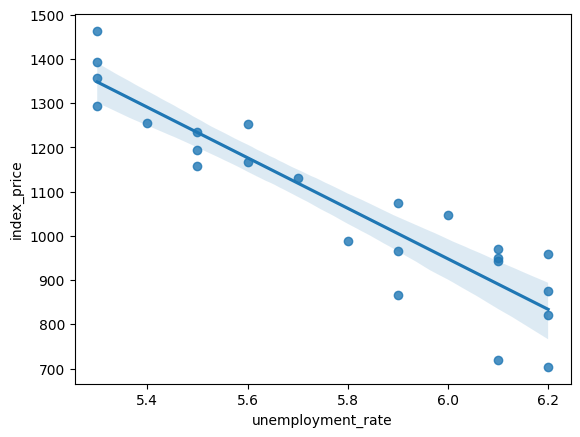

In [17]:
sns.regplot(x='unemployment_rate', y='index_price', data=df)

<Axes: xlabel='interest_rate', ylabel='index_price'>

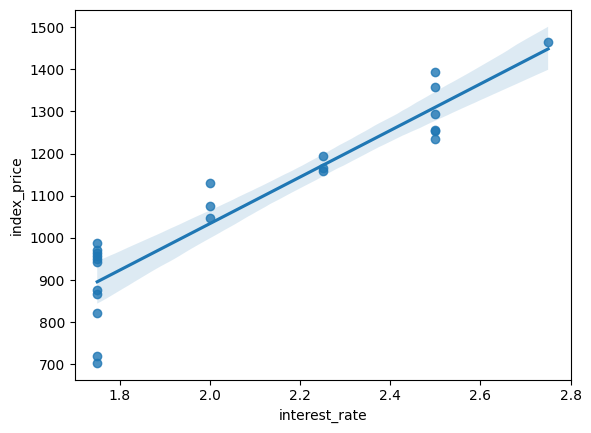

In [18]:
sns.regplot(x='interest_rate', y='index_price', data=df)

In [19]:
## now do the Regression
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [20]:
X_train=scaler.fit_transform(X_train)

In [23]:
X_test=scaler.transform(X_test)

In [24]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression(n_jobs=-1)

In [25]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
y_pred=regression.predict(X_test)

In [27]:
y_pred

array([1207.28987554,  829.59789771, 1401.54706621,  866.28485514,
       1000.10040791, 1170.6029181 ])

In [29]:
import numpy as np

In [31]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

5864.017665831333
66.72709444618776
76.57687422343206


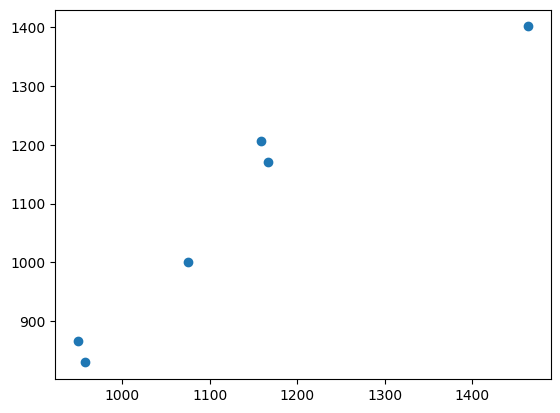

In [32]:
plt.scatter(y_test,y_pred)

In [33]:
residuals=y_test-y_pred
print(residuals)

8     -48.289876
16    128.402102
0      62.452934
18     82.715145
11     74.899592
9      -3.602918
Name: index_price, dtype: float64


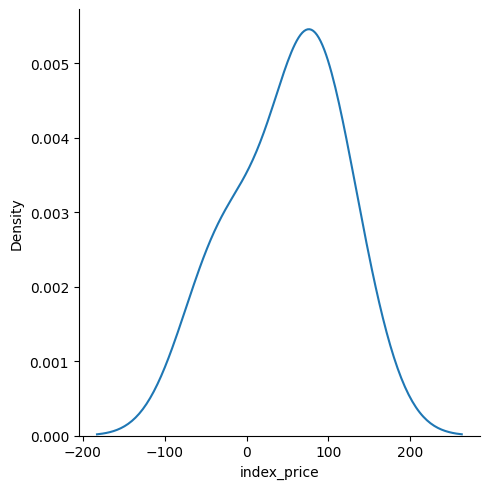

In [35]:
## Plot the residual
sns.displot(residuals,kind='kde')

In [36]:
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()

In [37]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.034
Model:                            OLS   Adj. R-squared (uncentered):             -0.087
Method:                 Least Squares   F-statistic:                             0.2808
Date:                Sat, 24 Jan 2026   Prob (F-statistic):                       0.759
Time:                        22:05:49   Log-Likelihood:                         -150.90
No. Observations:                  18   AIC:                                      305.8
Df Residuals:                      16   BIC:                                      307.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            81.9760    651.548      0.126      0.901   -1299.245    1463.197
x2          -120.5967    651.548     -0.185      0.855   -1501.818    1260.624
==============================================================================
Omnibus:                        1.471   Durbin-Watson:                   0.008
Prob(Omnibus):                  0.479   Jarque-Bera (JB):                1.094
Skew:                          -0.573   Prob(JB):                        0.579
Kurtosis:                       2.617   Cond. No.                         4.71
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [38]:
Slope=regression.coef_
print(Slope)

[  81.97602384 -120.5966506 ]


In [39]:
Y_intercept=regression.intercept_
print(Y_intercept)

1056.3333333333328
